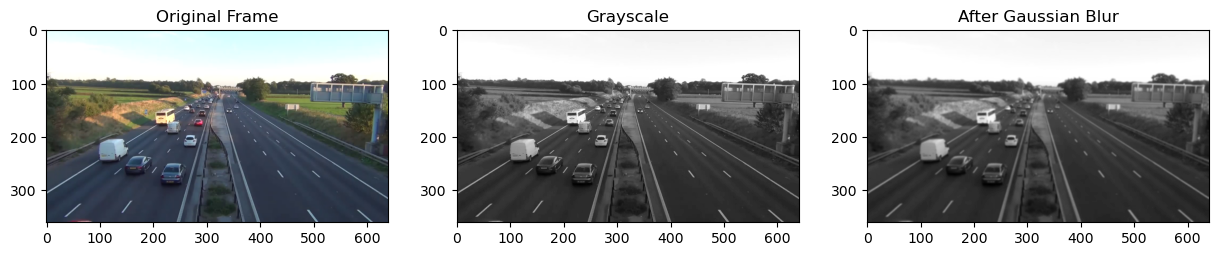

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


video_path = "D:/VehicleCounter/videos/video1.mp4"
cap = cv2.VideoCapture(video_path)


ret, frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read video.")
else:
   
    frame = cv2.resize(frame, (640, 360))

   
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

   
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

   
    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); plt.title("Original Frame")
    plt.subplot(1,3,2); plt.imshow(gray, cmap='gray'); plt.title("Grayscale")
    plt.subplot(1,3,3); plt.imshow(blur, cmap='gray'); plt.title("After Gaussian Blur")
    plt.show()


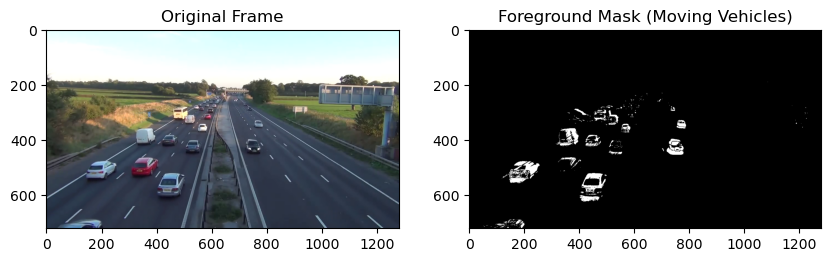

In [3]:

bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=50, detectShadows=False)


cap = cv2.VideoCapture(video_path)


for _ in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    fg_mask = bg_subtractor.apply(blur)

cap.release()


plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)); plt.title("Original Frame")
plt.subplot(1,2,2); plt.imshow(fg_mask, cmap='gray'); plt.title("Foreground Mask (Moving Vehicles)")
plt.show()


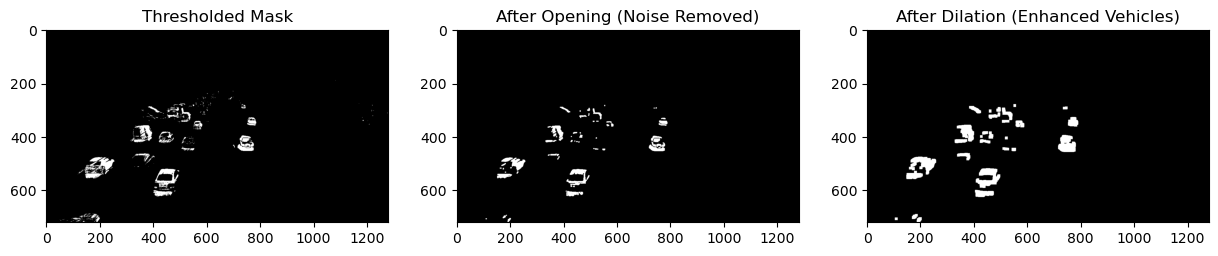

In [5]:

_, mask_thresh = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)


kernel = np.ones((4,4), np.uint8)
mask_open = cv2.morphologyEx(mask_thresh, cv2.MORPH_OPEN, kernel)


mask_dilate = cv2.dilate(mask_open, None, iterations=3)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(mask_thresh, cmap='gray'); plt.title("Thresholded Mask")
plt.subplot(1,3,2); plt.imshow(mask_open, cmap='gray'); plt.title("After Opening (Noise Removed)")
plt.subplot(1,3,3); plt.imshow(mask_dilate, cmap='gray'); plt.title("After Dilation (Enhanced Vehicles)")
plt.show()


In [2]:
import cv2
import numpy as np
import os
import glob

print("--- Script Started! Searching for videos... ---")


video_files = glob.glob("D:/VehicleCounter/videos/video1.mp4")
print(f"--- Found {len(video_files)} videos to process. ---")
if not video_files:
    print("--- ERROR: No .mp4 videos found in the 'videos' folder ---")
    exit()


class EuclideanDistTracker:
    def __init__(self):
        self.center_points = {}
        self.id_count = 0

    def update(self, objects_rect):
        objects_bbs_ids = []
        for rect in objects_rect:
            x, y, w, h = rect
            cx = (x + x + w) // 2
            cy = (y + y + h) // 2

            same_object_detected = False
            for id, pt in self.center_points.items():
                dist = np.sqrt((cx - pt[0]) ** 2 + (cy - pt[1]) ** 2)
                if dist < 45:
                    self.center_points[id] = (cx, cy)
                    objects_bbs_ids.append([x, y, w, h, id])
                    same_object_detected = True
                    break

            if not same_object_detected:
                self.center_points[self.id_count] = (cx, cy)
                objects_bbs_ids.append([x, y, w, h, self.id_count])
                self.id_count += 1

        new_center_points = {}
        for obj_bb_id in objects_bbs_ids:
            _, _, _, _, object_id = obj_bb_id
            center = self.center_points[object_id]
            new_center_points[object_id] = center
        self.center_points = new_center_points
        return objects_bbs_ids



for video_path in video_files:
    print(f"\n--- Processing Video: {os.path.basename(video_path)} ---")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open {video_path}")
        continue

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Parameters
    VAR_THRESHOLD = 50
    CONTOUR_AREA_THRESHOLD = 800
    STABLE_TRACK_FRAME_LIMIT = 7

    # ROI setup
    roi_polygon = np.array([[(0, height - 100), (width, height - 100), (width, int(height * 0.5)), (0, int(height * 0.5))]], np.int32)
    roi_mask = np.zeros((height, width), dtype=np.uint8)
    cv2.fillPoly(roi_mask, [roi_polygon], 255)

    # Counting lines
    line_down_y = int(height * 0.7)
    line_up_y = int(height * 0.6)

    
    bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=1000, varThreshold=VAR_THRESHOLD, detectShadows=False)
    tracker = EuclideanDistTracker()
    kernel = np.ones((4, 4), np.uint8)

    up_count = 0
    down_count = 0
    vehicle_info = {}
    frame_nmr = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_nmr += 1

        # Step 1: Preprocessing
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        # Step 2: Background Subtraction
        fg_mask_raw = bg_subtractor.apply(blur)
        _, fg_mask_raw = cv2.threshold(fg_mask_raw, 250, 255, cv2.THRESH_BINARY)

        # Step 3: Morphological Operations
        opened_mask = cv2.morphologyEx(fg_mask_raw, cv2.MORPH_OPEN, kernel)
        dilated_mask = cv2.dilate(opened_mask, None, iterations=3)

        # Step 4: Apply ROI
        roi_applied_mask = cv2.bitwise_and(dilated_mask, roi_mask)

        # Step 5: Contour Detection
        contours, _ = cv2.findContours(roi_applied_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        detections = []
        for contour in contours:
            if cv2.contourArea(contour) > CONTOUR_AREA_THRESHOLD:
                x, y, w, h = cv2.boundingRect(contour)
                detections.append([x, y, w, h])

        # Step 6: Object Tracking
        tracked_objects = tracker.update(detections)

        # Step 7: Vehicle Counting
        final_result_frame = frame.copy()
        cv2.polylines(final_result_frame, [roi_polygon], isClosed=True, color=(255, 255, 0), thickness=2)
        cv2.line(final_result_frame, (0, line_up_y), (width, line_up_y), (255, 0, 0), 2)
        cv2.line(final_result_frame, (0, line_down_y), (width, line_down_y), (0, 0, 255), 2)

        for obj in tracked_objects:
            x, y, w, h, obj_id = obj
            center_y = (y + y + h) // 2

            if obj_id not in vehicle_info:
                vehicle_info[obj_id] = {'start_frame': frame_nmr, 'counted': False}

            is_stable_track = (frame_nmr - vehicle_info[obj_id]['start_frame']) > STABLE_TRACK_FRAME_LIMIT

            if is_stable_track:
                if center_y > line_down_y and 'crossed_up' in vehicle_info[obj_id] and not vehicle_info[obj_id]['counted']:
                    down_count += 1
                    vehicle_info[obj_id]['counted'] = True
                if center_y > line_up_y:
                    vehicle_info[obj_id]['crossed_up'] = True

                if center_y < line_up_y and 'crossed_down' in vehicle_info[obj_id] and not vehicle_info[obj_id]['counted']:
                    up_count += 1
                    vehicle_info[obj_id]['counted'] = True
                if center_y < line_down_y:
                    vehicle_info[obj_id]['crossed_down'] = True

            cv2.rectangle(final_result_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(final_result_frame, f"ID: {obj_id}", (x, y - 10), cv2.FONT_HERSHEY_PLAIN, 1, (255, 255, 255), 1)

        # Step 8: Display Results
        cv2.putText(final_result_frame, f"Up: {up_count}", (10, height - 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        cv2.putText(final_result_frame, f"Down: {down_count}", (10, height - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        cv2.imshow(f"Processing: {os.path.basename(video_path)}", final_result_frame)

        key = cv2.waitKey(30)
        if key == ord('q'):
            break

    print(f" Results for {os.path.basename(video_path)} ")
    print(f"Total Vehicles Counted Going Up: {up_count}")
    print(f"Total Vehicles Counted Going Down: {down_count}")

    cap.release()
    cv2.destroyAllWindows()

print("\n All videos processed!")


--- Script Started! Searching for videos... ---
--- Found 1 videos to process. ---

--- Processing Video: video1.mp4 ---
 Results for video1.mp4 
Total Vehicles Counted Going Up: 40
Total Vehicles Counted Going Down: 52

 All videos processed!
